## 1. Setup

In [1]:
!pip install --quiet accelerate
!pip install --quiet bitsandbytes
!pip install --quiet peft
!pip install --quiet trl
!pip install --quiet datasets
!pip install --quiet multiprocess
!pip install --quiet -U nnsight
!pip install --quiet seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ['CUDA_LAUNCH_BLOCKING']='1'

In [3]:
from transformers import AutoTokenizer, GenerationConfig
from huggingface_hub import hf_hub_download, login

from nnsight import LanguageModel

import torch
import numpy as np

import math
import gc

import json

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import binned_statistic

from IPython.display import HTML

In [4]:
device_count = torch.cuda.device_count()
devices = []

for i in range(device_count):
    devices.append(f"cuda:{i}")

In [ ]:
hf_token = '' # use your hf token

In [6]:
login(token=hf_token)

In [7]:
repo_id = "microsoft/lost_in_conversation"
filename = "lost_in_conversation.json"

tasks_dataset = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")

In [8]:
with open(tasks_dataset) as f:
    data = json.load(f)

In [9]:
coding_tasks = [item for item in data if item.get('task', "") == "code"]
print(coding_tasks[0])

{'task_id': 'sharded-HumanEval/105', 'prompt': '\ndef by_length(arr):\n    """\n    Given an array of integers, sort the integers that are between 1 and 9 inclusive,\n    reverse the resulting array, and then replace each digit by its corresponding name from\n    "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine".\n\n    For example:\n      arr = [2, 1, 1, 4, 5, 8, 2, 3]   \n            -> sort arr -> [1, 1, 2, 2, 3, 4, 5, 8] \n            -> reverse arr -> [8, 5, 4, 3, 2, 2, 1, 1]\n      return ["Eight", "Five", "Four", "Three", "Two", "Two", "One", "One"]\n    \n      If the array is empty, return an empty array:\n      arr = []\n      return []\n    \n      If the array has any strange number ignore it:\n      arr = [1, -1 , 55] \n            -> sort arr -> [-1, 1, 55]\n            -> reverse arr -> [55, 1, -1]\n      return = [\'One\']\n    """\n', 'test': 'def check(candidate):\n\n    # Check some simple cases\n    assert True, "This prints if this assert fails

In [10]:
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"

workers = []
dtype = torch.float16

for i in range(1):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = LanguageModel(MODEL_NAME, output_attentions=True, device_map="auto", dispatch=True)
    workers.append((model, tokenizer))

tokenizer = workers[0][1]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [11]:
generation_kwargs = dict(
    max_new_tokens=1024,
    do_sample=False,
    pad_token_id=tokenizer.pad_token_id,
)

generation_config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,
    pad_token_id=tokenizer.pad_token_id,
)

In [12]:
prompt_content = """
You are an expert Python programmer. You will be given a question (problem specification) and will generate a correct Python program that matches the specification and passes all tests.

Format:
- [Standalone] Make sure that your answer consists of only one Python function at the top level. Do not wrap with a class or split into multiple functions.
"""

system_prompt = {"role": "system", "content": prompt_content}

def prepare_messages(messages):
  return [system_prompt] + messages

With the next visualization tool we can see exactly which tokens match the final generation and how confident the model is when it selects them.
But it will take a lot of space in your notebook, so comment it out if you don't need it - there is a graph anyway!

In [13]:
def format_token(token):
    return token.replace(' ', '&nbsp;').replace('\t', '&nbsp;' * 4)

def visualize_in_html(tokens, values, color=None, key=None):
    html = ""
    for token, v in zip(tokens, values):
        rgba = [0] * 4
        if color is not None:
            for i, c in enumerate(color[:4]):
                rgba[i] = c

        if key is None:
            value = v
        else:
            value = key(v)

        if isinstance(value, (float, int)):
            rgba[3]=value
        else:
            for i, c in enumerate(value[:4]):
                rgba[i] = c


        background_color = f"rgba({rgba[0]}, {rgba[1]}, {rgba[2]}, {rgba[3]:.3f})"

        if token.startswith('\n') and token != '\n':
            html += "<br>"

        html += f"<span style='background-color:{background_color}; padding:2px;' title='{rgba[3]:.3f}'>{format_token(token)}</span>"

        if token.endswith('\n'):
            html += "<br>"

    return html

In [14]:
def cleanup():
  gc.collect()
  torch.cuda.empty_cache()

In [15]:
cleanup()

In [16]:
LOGIT_DIM = model.config.vocab_size

In [17]:
tasks = coding_tasks

## 2. Selecting hyperparameters

### 2.1 Layer

In [18]:
prompts = []
for task in tasks[:5]:
    prompt = task.get('question_content', None)
    if prompt is not None:
      prompts.append(prompt)
      continue

    prompt = task.get('prompt', None)
    if prompt is not None:
      prompts.append(prompt)
      continue

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def silhouette(X):
  X = X.reshape(-1, 1)
  kmeans = KMeans(n_clusters=2, n_init=10).fit(X)
  score = silhouette_score(X, kmeans.labels_)

  return max(score, 0)

We will select the layer first so we do not need to sample layer count times activations to tune other parameters.

In [20]:
def estimate_decisions(messages, layers=[-1], target_pass_ratio=0.05):
    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]

    prompt = tokenizer.apply_chat_template(
      messages,
      return_tensors='pt', tokenize=True, add_generation_prompt=True
    )

    output_layers = [model.model.layers[l] for l in layers]
    entropies = {l: [] for l in layers}
    varentropies = {l: [] for l in layers}
    lens_tokens = {l: [] for l in layers}
    tokens = []

    with model.generate(prompt, max_new_tokens=1024, do_sample=False) as tracer:
        with tracer.iter[:]:
            for l, output_layer in zip(layers, output_layers):
              all_logits = model.lm_head(model.model.norm(output_layer.output[0]))
              logits = all_logits[-1].unsqueeze(0)
              probs = torch.nn.functional.softmax(logits, dim=-1)
              log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
              entropy = -torch.sum(probs * log_probs, dim=-1).cpu().save()
              entropies[l].extend(entropy.tolist())

              varentropy = torch.sum(
                probs.cpu() * (log_probs.cpu() + entropy.unsqueeze(-1))**2, dim=-1
              ).save()
              varentropies[l].extend(varentropy.tolist())

              lens_tokens[l].append(logits[0].argmax(dim=-1))
            tokens.append(model.lm_head.output[0, -1].argmax(dim=-1))

    match_ratios = []
    entropy_clusterabilities = []
    varentropy_clusterabilities = []
    pass_ratios = []

    for i, l in enumerate(layers):
      tokens_one_by_one = [model.tokenizer.decode([t]) for t in tokens]
      tokens_match = [1 if l_t == t else 0 for t, l_t in zip(tokens, lens_tokens[l])]

      def coloring_closure(data):
          entropy, matches = data
          return 255 * (1 - matches), 0, 255 * matches, (1 - (entropy / np.log(LOGIT_DIM)))**2

      scores = [math.sqrt(v * e) for v, e in zip(entropies[l], varentropies[l])]
      html = visualize_in_html(
        tokens_one_by_one, list(zip(scores, tokens_match)),
        (255, 0, 0), lambda et: coloring_closure(et)
      )
      print(i)
      display(HTML(html))

      match_ratio = sum(tokens_match) / len(tokens_match)
      match_ratios.append(match_ratio)
      print(f"Match ratio: {match_ratio}")

      scaled_entropies = np.array(np.sort(entropies[l]) / np.log(LOGIT_DIM))
      entropy_clusterability = silhouette(scaled_entropies)
      entropy_clusterabilities.append(entropy_clusterability)

      scaled_varentropies = np.array(4 * np.sort(varentropies[l]) / np.log(LOGIT_DIM) ** 2)
      varentropy_clusterability = silhouette(scaled_varentropies)
      varentropy_clusterabilities.append(varentropy_clusterability)

      print(f"Entropy clusterability: {entropy_clusterability}")
      print(f"Varentropy clusterability: {varentropy_clusterability}")

      scaled_entropies = np.array(scaled_entropies)[:, np.newaxis]
      scaled_varentropies = np.array(scaled_varentropies)[:, np.newaxis]

      cluster = GaussianMixture(n_components=2)
      labels = cluster.fit_predict(scaled_entropies)
      centers = np.sort(cluster.means_.flatten())
      entropies_threshold = np.mean(centers)

      cluster = GaussianMixture(n_components=2)
      labels = cluster.fit_predict(scaled_varentropies)
      centers = np.sort(cluster.means_.flatten())
      varentropies_threshold = np.mean(centers)

      X = np.concatenate((scaled_entropies, scaled_varentropies), axis=1)
      threshold_mask = np.where(X > np.array([entropies_threshold, varentropies_threshold]), 1, 0)
      pass_ratio = (threshold_mask[:, 0] * threshold_mask[:, 1]).mean()
      pass_ratios.append(pass_ratio)
      print(f"Pass ratio: {pass_ratio}")

    ax = sns.lineplot(x=layers, y=match_ratios, label='Match ratio')
    clusterability = np.array(entropy_clusterabilities) * np.array(varentropy_clusterabilities)
    sns.lineplot(x=layers, y=clusterability, label='Clusterability', ax=ax)
    score = np.array(match_ratios) * clusterability

    sns.lineplot(x=layers, y=pass_ratios, label='Pass ratio', ax=ax)
    ax.axhline(y=target_pass_ratio, color='black', linestyle='--')
    deviation = np.abs(np.array(pass_ratios) - target_pass_ratio)

    x = np.argmax(score - deviation)
    sns.lineplot(x=layers, y=(score - deviation), label='Total score', ax=ax)
    ax.axvline(x=layers[x], color='red', linestyle='--')
    plt.ylabel('Value')
    plt.xlabel('Layer')
    plt.legend()
    plt.show()

    return x

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] You have set `compile_config`, but we are unable to meet the criteria for compilation. Compilation will be skipped.


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nnsight/intervention/interleaver.py:733: UserWarning: Execution complete but `model.model.layers.0.output.i462` was not provided. If this was in an Iterator at iteration 462 this iteration did not happen. If you were using `.iter[:]`, this is likely not an error.
  warnings.warn(msg)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


0


Match ratio: 0.0
Entropy clusterability: 0.9246372584234539
Varentropy clusterability: 0.9224216244643396
Pass ratio: 0.08441558441558442
1


Match ratio: 0.0
Entropy clusterability: 0.8016800028807095
Varentropy clusterability: 0.7349042755825065
Pass ratio: 0.35714285714285715
2


...

Match ratio: 0.24025974025974026
Entropy clusterability: 0.7826813541173585
Varentropy clusterability: 0.6841590457817026
Pass ratio: 0.3051948051948052
12


Match ratio: 0.5173160173160173
Entropy clusterability: 0.7608909978125156
Varentropy clusterability: 0.6705092672944487
Pass ratio: 0.3268398268398268
13


Match ratio: 0.7922077922077922
Entropy clusterability: 0.7628136589487472
Varentropy clusterability: 0.7165374386054032
Pass ratio: 0.30303030303030304
14


Match ratio: 0.9242424242424242
Entropy clusterability: 0.7667507545919362
Varentropy clusterability: 0.8621077682262901
Pass ratio: 0.11038961038961038
15


Match ratio: 1.0
Entropy clusterability: 0.8183620640857877
Varentropy clusterability: 0.7893141369340472
Pass ratio: 0.23809523809523808


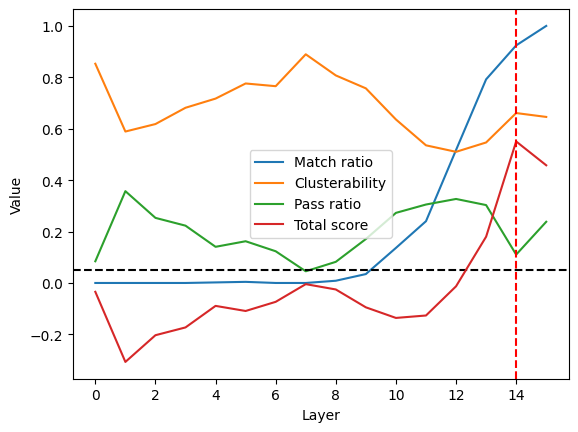

In [21]:
layer = estimate_decisions(prompts[0], layers=list(range(len(model.model.layers))))

As you can see layer 14 provides a good balance between states that match the final result and states which entropies can be separated well.

In [22]:
cleanup()

In [23]:
def merge_dicts(dict1, dict2):
  merged = dict1.copy()
  for key, val2 in dict2.items():
    merged[key] = merged.get(key, []) + val2

  return merged

Now we can build a bigger activation dataset as we now know what layer we will be using. We will also sample logits so that we can see how cosine distance affects KL.

In [24]:
def build_activations_dataset(prompts_dataset, activation_layers=[-1], logit_layers=None):
    if logit_layers is None:
      logit_layers = activation_layers

    layers = set(activation_layers + logit_layers)

    def gather_activations(messages, layers):
        if isinstance(messages, str):
            messages = [{"role": "user", "content": messages}]

        prompt = tokenizer.apply_chat_template(messages, return_tensors='pt', tokenize=True, add_generation_prompt=True)
        output_layers = [model.model.layers[l] for l in layers]
        activations = {l: [] for l in layers}
        logits = {l: [] for l in layers}

        with model.generate(prompt, max_new_tokens=1024, do_sample=False) as tracer:
            with tracer.iter[:]:
                for l, output_layer in zip(layers, output_layers):
                  all_activations = output_layer.output[0]
                  last_activations = all_activations[-1]
                  last_logits = model.lm_head(model.model.norm(last_activations.unsqueeze(0)))[0]
                  if l in activation_layers:
                    activations[l].append(last_activations.detach().cpu())
                  if l in logit_layers:
                    logits[l].append(last_logits.detach().cpu())

        return activations, logits

    all_activations = {}
    all_logits = {}
    for prompt in prompts_dataset:
        activations, logits = gather_activations(prompt, layers)
        all_activations = merge_dicts(all_activations, activations)
        all_logits = merge_dicts(all_logits, logits)

    return all_activations, all_logits

In [25]:
activations, logits = build_activations_dataset(prompts, activation_layers=[layer], logit_layers=[-1, layer])

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nnsight/intervention/interleaver.py:733: UserWarning: Execution complete but `model.model.layers.14.output.i462` was not provided. If this was in an Iterator at iteration 462 this iteration did not happen. If you were using `.iter[:]`, this is likely not an error.
  warnings.warn(msg)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nnsight/intervention/interleaver.py:733: UserWarning: Execution complete but `model.model.layers.14.output.i324` was not provided. If this was in an Iterator at iteration 324 this iteration did not happen. If you were using `.iter[:]`, this is likely not an error.
  warnings.warn(msg)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/zeus/miniconda3/envs/clo

In [26]:
activations_dataset = activations[layer]

logits_dataset = logits[-1]
logit_lens_dataset = logits[layer]

### 2.2 Entropy thresholds

With richer dataset we can derive more accurate thresholds, now also analyzing entropy and varentropy as joint distribution

In [29]:
def clusterize_activations(activations_dataset):
    entropies = []
    varentropies = []

    for logits in activations_dataset:
        probs = torch.nn.functional.softmax(logits, dim=-1)
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        entropy = -torch.sum(probs * log_probs, dim=-1)
        entropies.append(entropy.item() / np.log(LOGIT_DIM))

        varentropy = torch.sum(probs * (log_probs + entropy.unsqueeze(-1))**2, dim=-1)
        varentropies.append(4 * varentropy.item() / np.log(LOGIT_DIM) ** 2)

    def plot(X, labels):
        _, ax = plt.subplots(figsize=(10, 4))
        unique_labels = set(labels)
        colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]

            class_index = (labels == k).nonzero()[0]
            for ci in class_index:
                ax.plot(
                    X[ci, 0],
                    X[ci, 1] if X.shape[1] > 1 else 0,
                    "x" if k == -1 else "o",
                    markerfacecolor=tuple(col),
                    markeredgecolor="k",
                    markersize=8
                )

        plt.tight_layout()

    entropies = np.array(entropies)[:, np.newaxis]
    varentropies = np.array(varentropies)[:, np.newaxis]

    X = np.concatenate((entropies, varentropies), axis=1)
    cluster = GaussianMixture(n_components=4, random_state=0)
    labels = cluster.fit_predict(X)

    _, ids = torch.topk(-torch.tensor(cluster.means_[:, 0]), 2)
    threshold_cluster_index = ids[1]

    mask = labels == threshold_cluster_index
    entropies_2d_threshold = np.max(X[mask, 0])
    varentropies_2d_threshold = np.max(X[mask, 1])

    entropy_mask = X[:, 0] >= entropies_2d_threshold
    varentropy_mask = X[:, 1] >= varentropies_2d_threshold

    plot(X, labels)
    plt.axvline(x=entropies_2d_threshold, color='blue', linestyle='-.')
    plt.axhline(y=varentropies_2d_threshold, color='blue', linestyle='-.')

    plt.xlabel("Entropy")
    plt.ylabel("Varentropy")
    plt.show()

    return entropies_2d_threshold, varentropies_2d_threshold

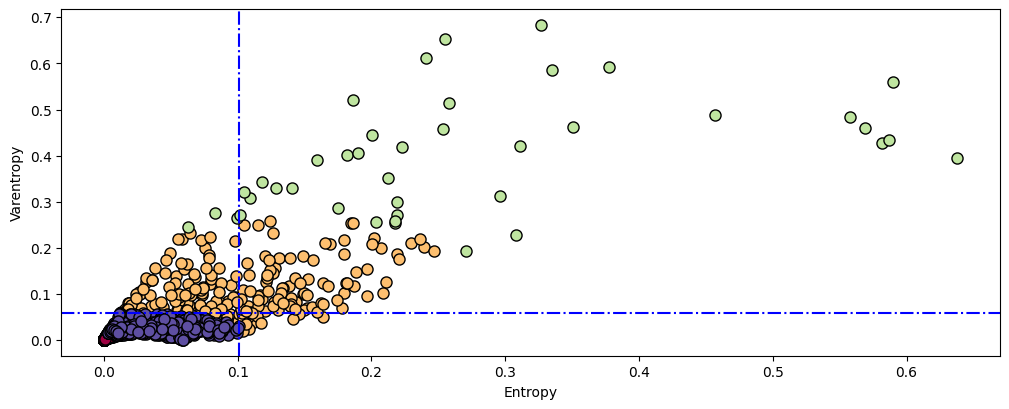

In [30]:
entropies_threshold, varentropies_threshold = clusterize_activations(logit_lens_dataset)

In [31]:
cleanup()

Now we can index the dataset by whether it passes the threshold to filter it fast

In [32]:
def get_threshold_index(activations_dataset, threshold):
  index = []

  for i, logits in enumerate(activations_dataset):
      probs = torch.nn.functional.softmax(logits, dim=-1)
      log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
      entropy = -torch.sum(probs * log_probs, dim=-1) / np.log(LOGIT_DIM)
      varentropy = 4 * torch.sum(probs.cpu() * (log_probs + entropy.unsqueeze(-1))**2, dim=-1) / np.log(LOGIT_DIM)**2

      if entropy > threshold[0] and varentropy > threshold[1]:
          index.append(i)

  return index

### 2.3 Resampling temperature

As we will (at least initially) work exclusively with the states that passed the threshold we can tune temperatures on them only. We will track the probabilities of selecting top-1 token vs top-32 - top-1 token to make our choice.

In [33]:
def tune_temperature(activations_dataset, n=10, max_t=10):
    temperatures = np.arange(0.0, max_t + 1e-6, 0.1)
    entropies_by_temperature = []

    for t in temperatures:
        for i, logits in enumerate(activations_dataset):
            probs = torch.nn.functional.softmax(logits / t, dim=-1)
            log_probs = torch.nn.functional.log_softmax(logits / t, dim=-1)
            entropy = -torch.sum(probs * log_probs, dim=-1).item() / np.log(LOGIT_DIM)

            top_1_probability = torch.max(probs).item()
            top_n, _ = torch.topk(probs, k=n)
            top_n_probability = torch.sum(top_n).item()
            exploration_probability = top_n_probability - top_1_probability

            entropies_by_temperature.append({
                'temperature': t,
                'id': i,
                'value': entropy,
                'metric': 'Entropy'
            })

            entropies_by_temperature.append({
                'temperature': t,
                'id': i,
                'value': top_1_probability,
                'metric': 'Top-1 probability'
            })

            entropies_by_temperature.append({
                'temperature': t,
                'id': i,
                'value': top_n_probability,
                'metric': f'Top-{n} probability'
            })

            entropies_by_temperature.append({
                'temperature': t,
                'id': i,
                'value': exploration_probability,
                'metric': 'Exploration probability'
            })

    df = pd.DataFrame(entropies_by_temperature)
    sns.lineplot(df, x='temperature', y='value', hue='metric')

    pivot_df = df.pivot_table(index='temperature', columns='metric', values='value', aggfunc='mean')
    pivot_df = pivot_df.sort_index()
    exploration_breakpoint = pivot_df[pivot_df['Exploration probability'] > pivot_df['Top-1 probability']].index.min()
    plt.axvline(x=exploration_breakpoint, color='red', linestyle='--')
    plt.xlabel('Temperature')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return exploration_breakpoint

In [34]:
threshold_index = get_threshold_index(logit_lens_dataset, threshold=(entropies_threshold, varentropies_threshold))

In [35]:
cleanup()

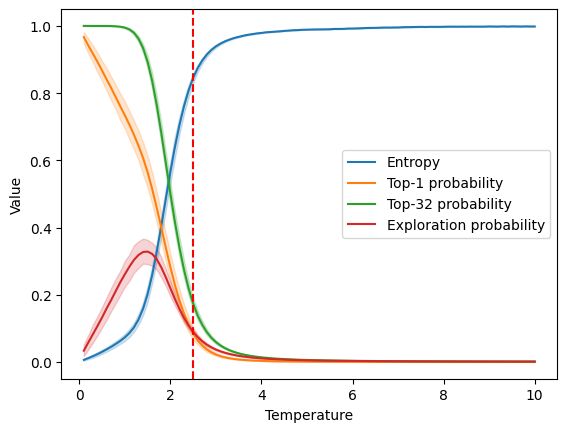

In [36]:
temperature = tune_temperature(torch.stack(logits_dataset)[threshold_index], n=32)

With the temperature ~2.5 exploration probability becomes higher than greedy token probability on average for the first time. We will use this value so that after the first pass (that will always match greedy decoding) we are almost guaranteed to explore.

### 2.4 VectorDSU threshold

Now we select the best threshold to use in `VectorDSU` given some expected max KL

In [37]:
def find_optimal_similarity_threshold(
  hidden_states, logits,
  bins=100, window_shape=3, kl_threshold=0.05, eps = 1e-9
):
  n = hidden_states.shape[0]
  probs = torch.nn.functional.softmax(logits, dim=-1)
  log_probs = torch.log(probs + eps)

  normalized_states = hidden_states / hidden_states.norm(dim=1, keepdim=True)
  cosine = normalized_states @ normalized_states.T

  cosine = cosine.flatten()[1:].view(n-1, n+1)[:,:-1].reshape(n, n-1)
  cosine = cosine.to(float).detach().cpu().numpy()

  entropy = (probs * log_probs).sum(dim=1)

  chunk_size = 16
  cross_entropy = torch.empty((n, n), dtype=probs.dtype, device='cpu')

  for i in range(0, n, chunk_size):
      end = min(i + chunk_size, n)
      chunk_result = probs[i:end] @ log_probs.T
      cross_entropy[i:end] = chunk_result
      del chunk_result
      cleanup()

  kl = entropy.unsqueeze(1) - cross_entropy

  kl = kl.flatten()[1:].view(n-1, n+1)[:,:-1].reshape(n, n-1)
  kl = 4 * kl.to(float).detach().cpu().numpy() / np.log(LOGIT_DIM) ** 2

  cosine_flat = cosine.flatten()
  kl_flat = kl.flatten()

  sort_index = np.argsort(cosine_flat)
  cosine_flat = cosine_flat[sort_index]
  kl_flat = kl_flat[sort_index]

  mean_statistic = binned_statistic(cosine_flat, kl_flat, bins=bins, statistic='mean')
  bins = mean_statistic.bin_edges
  bin_centers = sliding_window_view(bins, window_shape=2).mean(axis=1)
  kl_mean = mean_statistic.statistic
  var_statistic = binned_statistic(cosine_flat, kl_flat, bins=bins, statistic='std')
  kl_var = var_statistic.statistic

  pad_len = (window_shape // 2, window_shape // 2)
  kl_rolling_mean = sliding_window_view(np.pad(kl_mean, pad_len, 'edge'), window_shape=window_shape).mean(axis=-1)
  kl_rolling_var = sliding_window_view(np.pad(kl_var, pad_len, 'edge'), window_shape=window_shape).mean(axis=-1)

  lower_bound = np.clip(kl_rolling_mean - 2 * kl_rolling_var, 0, None)
  upper_bound = kl_rolling_mean + 2 * kl_rolling_var

  fig, ax = plt.subplots(figsize=(8, 5))

  ax.plot(bin_centers, kl_rolling_mean, label='Mean KL')
  ax.fill_between(
      bin_centers,
      lower_bound,
      upper_bound,
      alpha=0.2,
      linewidth=1
  )

  condition = (kl_rolling_mean + kl_rolling_var * 2) < kl_threshold
  idx = np.where(~condition)[0]
  idx = idx[-1] + 1 if idx.size > 0 else 0
  idx = min(bin_centers.shape[0]-1, idx)
  kl_under_threshold = bin_centers[idx]
  ax.axhline(y=kl_threshold, color='black', linestyle='--')
  ax.axvline(x=kl_under_threshold, color='red', linestyle='--')
  plt.xlabel("Cosine Similarity")
  plt.ylabel("KL Divergence")
  plt.title("Similarity vs. Divergence")
  plt.legend()
  plt.show()

  return kl_under_threshold

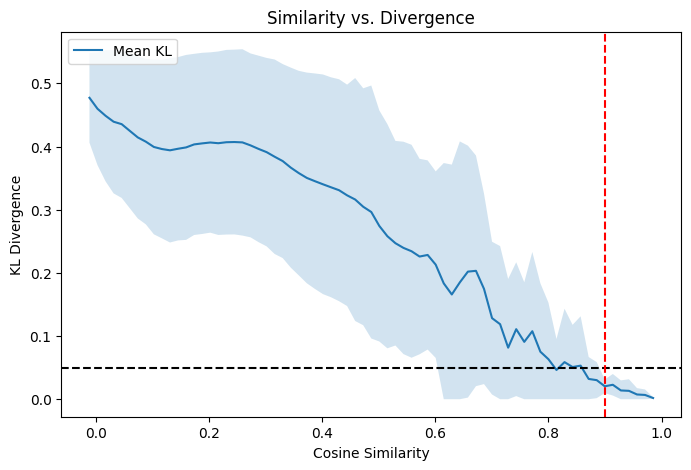

In [38]:
clustering_threshold = find_optimal_similarity_threshold(
  torch.stack(activations_dataset)[threshold_index],
  torch.stack(logit_lens_dataset)[threshold_index],
  bins=len(threshold_index) // 2
)

Finally, all the hyperparameters are selected and can be passed to the fleet worker!

In [39]:
print(f"Layer: {layer}")
print(f"Entropy thresholds: {entropies_threshold:.2f}, {varentropies_threshold:.2f}")
print(f"Scaling temperature: {temperature:.2f}")
print(f"Clustering threshold: {clustering_threshold:.2f}")

Layer: 14
Entropy thresholds: 0.10, 0.06
Scaling temperature: 2.50
Clustering threshold: 0.90
